In [2]:
import pandas as pd
import numpy as np

In [3]:
%pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib
print(matplotlib.__version__)



3.10.8


In [5]:
import matplotlib.pyplot as plt

In [6]:
import streamlit as st

In [7]:
df = pd.read_csv("Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Data Cleaning


In [11]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')         
# errors='coerce'-> If a value cannot be converted to a number, replace it with NaN (missing value) instead of throwing an error.

In [12]:
df=df.dropna()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [13]:
df.drop(columns=['customerID'], inplace=True) #remove customer id since It has NO analytical value. it is just an identifier
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


### Feature Extraction(Separating Columns)

In [14]:
categorical=df.select_dtypes(include='object').columns
categorical
#select_dtypes() selects columns based on their data type,include='object' selects text-based columns,.columns returns only the column names, not the data itself.

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [15]:
numerical=df.select_dtypes(exclude='object').columns
numerical

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

### Basic Analysis(EDA)

In [19]:
#Overall churn rate
churn_rate=df['Churn'].value_counts(normalize=True)*100
churn_rate

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [43]:
#Churn by contract type
contract_group=df.groupby('Contract')
contract_group['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


In [46]:
#Churn is max for which contract type?
churn_table=contract_group['Churn'].value_counts(normalize=True).unstack()
churn_table['Yes'].idxmax() #idxmax() -> returns which index has the max value

'Month-to-month'

In [40]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [60]:
#How many senior citizens left?
senior_table=df.groupby('SeniorCitizen')['Churn'].value_counts().unstack()
seniors_left=senior_table.loc[1,'Yes']
print(seniors_left)

476


In [97]:
#Percentage of each gender who left?
gender_table=df.groupby('gender')['Churn'].value_counts().unstack()
#gender_table
gender_left=gender_table.loc[:,'Yes']
gender_left

gender
Female    939
Male      930
Name: Yes, dtype: int64

### Data Visualization

Churn
No     5163
Yes    1869
Name: count, dtype: int64

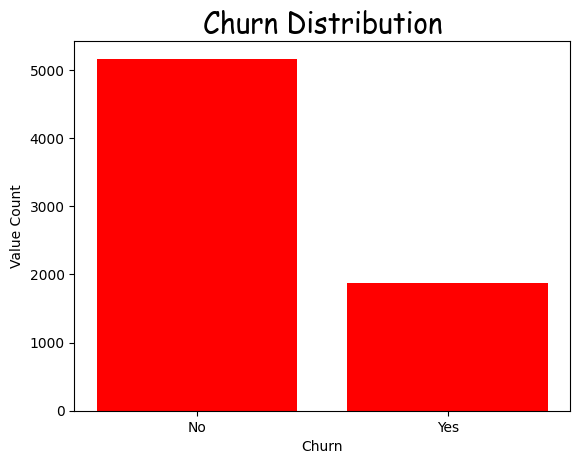

In [76]:
#1. Churn distribution
plt.bar(df['Churn'].unique(),df['Churn'].value_counts(),color='red')
plt.title('Churn Distribution',fontdict={'fontname':'Comic Sans MS','fontsize':20})
plt.xlabel('Churn')
plt.ylabel('Value Count')
#df['Churn'].unique()
df['Churn'].value_counts()

Contract
Month-to-month    1655
One year           166
Two year            48
Name: Yes, dtype: int64


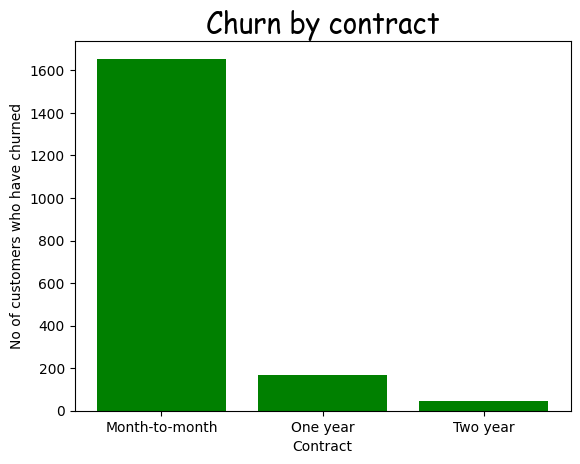

In [98]:
#2. Churn by contract
Churn_by_contract=df.groupby('Contract')['Churn'].value_counts().unstack()['Yes']
print(Churn_by_contract)
plt.bar(df['Contract'].unique(),df.groupby('Contract')['Churn'].value_counts().unstack()['Yes'],color='green')
plt.title('Churn by contract',fontdict={'fontname':'Comic Sans MS','fontsize':20})
plt.xlabel('Contract')
plt.ylabel('No of customers who have churned')
plt.show()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64



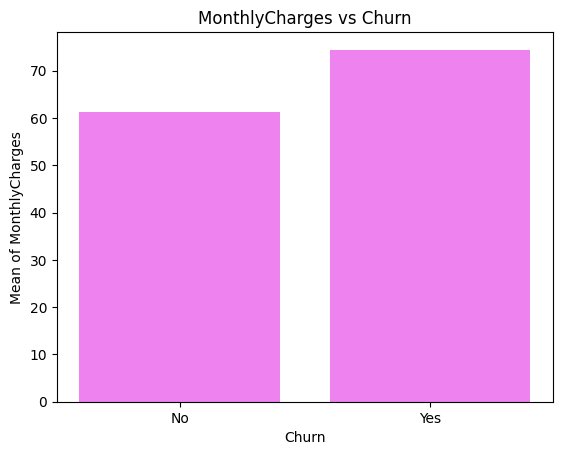

In [115]:
#Mean of MonthlyCharges vs Churn
print(df.groupby('Churn')['MonthlyCharges'].mean())
print()
plt.bar(df['Churn'].unique(),df.groupby('Churn')['MonthlyCharges'].mean(),color='violet')
plt.title('MonthlyCharges vs Churn')
plt.xlabel('Churn');
plt.ylabel('Mean of MonthlyCharges')
plt.show()

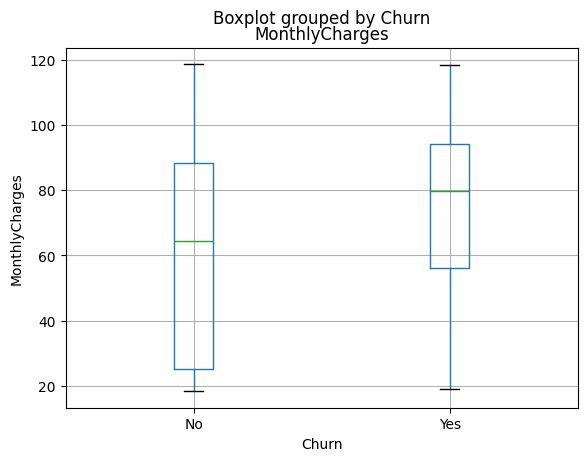

In [118]:
#. Monthly charges vs churn
df.boxplot(column='MonthlyCharges', by='Churn')
plt.ylabel('MonthlyCharges')
plt.show()
